# 03 - Department Analysis

**Objective:** Compare budget allocation, utilization, and efficiency across the 8 departments.

**Business context:** Departments are the closest available dimension to 'customer' in this dataset - they are the units that hold and spend budget. This notebook replaces the originally-planned customer-analysis notebook for that reason.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from data_loading import load_dataset
from data_cleaning import clean_dataset
from feature_engineering import engineer_features
import kpi_calculations as kpi


In [2]:
raw = load_dataset()
cleaned, _ = clean_dataset(raw)
df = engineer_features(cleaned)
by_dept = kpi.kpis_by_department(df)
by_dept.round(4)

,total_allocated,total_utilized,supplied_budget_variance,avg_allocation_efficiency,record_count,utilization_rate,computed_budget_gap
department,,,,,,,
HR,1.370477e+08,1.283121e+08,-374775.77,83.9408,904,0.9363,8735575.61
Logistics,1.338629e+08,1.289283e+08,128557.27,84.3153,886,0.9631,4934536.06
Sales,1.281962e+08,1.216852e+08,10169.54,84.2130,841,0.9492,6510989.67
R&D,1.255342e+08,1.223333e+08,-155856.40,84.2486,843,0.9745,3200851.34
IT,1.250134e+08,1.215319e+08,147678.68,83.9904,843,0.9722,3481474.38
Operations,1.240421e+08,1.183564e+08,-48301.05,83.9822,833,0.9542,5685644.05
Marketing,1.237979e+08,1.199135e+08,43381.63,83.9694,816,0.9686,3884369.68
Finance,1.222888e+08,1.178229e+08,-111017.89,83.6575,814,0.9635,4465855.89


## Q: Which departments hold the largest budgets, and how does utilization compare?

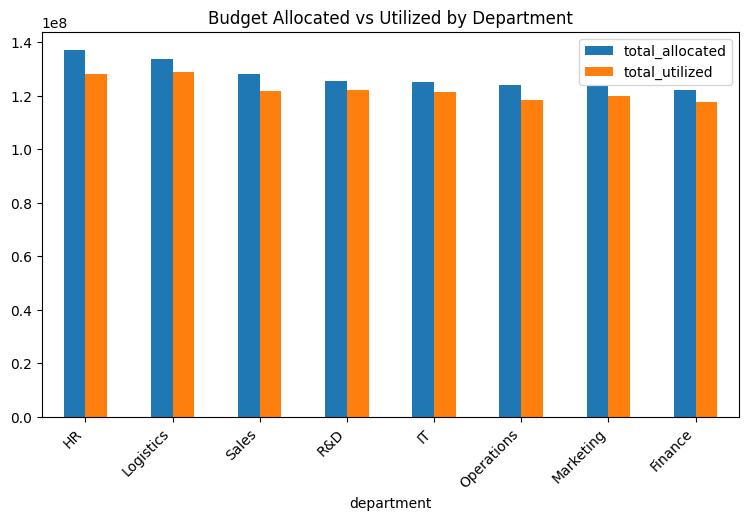

In [3]:
fig, ax = plt.subplots(figsize=(9,5))
by_dept[['total_allocated','total_utilized']].plot(kind='bar', ax=ax)
ax.set_title('Budget Allocated vs Utilized by Department')
plt.xticks(rotation=45, ha='right')
plt.show()

## Q: Which departments are, on average, over budget?

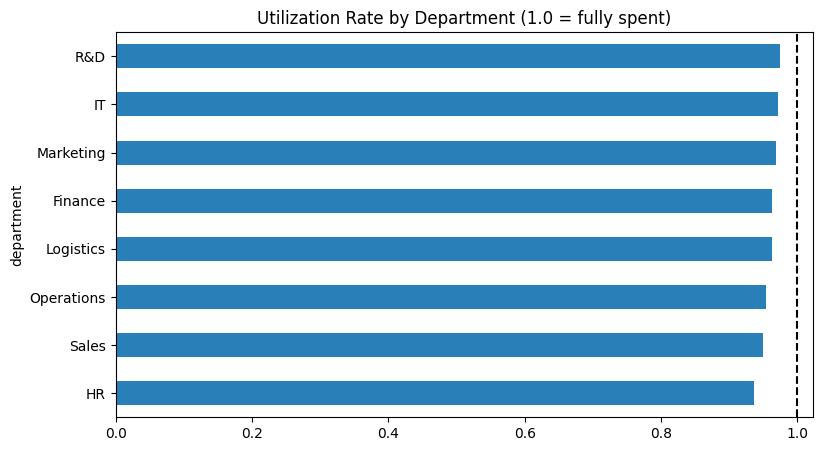

In [4]:
fig, ax = plt.subplots(figsize=(9,5))
data = by_dept['utilization_rate'].sort_values()
colors = ['#c0392b' if v>1 else '#2980b9' for v in data.values]
data.plot(kind='barh', ax=ax, color=colors)
ax.axvline(1.0, color='black', linestyle='--')
ax.set_title('Utilization Rate by Department (1.0 = fully spent)')
plt.show()

## Q: What share of each department's records are 'Inefficient'?

In [5]:
pct_inefficient = (
    df.groupby('department', observed=True)['budget_status']
      .apply(lambda s: (s=='Inefficient').mean())
      .sort_values(ascending=False)
)
pct_inefficient.round(4)

department
HR            0.3473
IT            0.3464
Logistics     0.3442
R&D           0.3298
Operations    0.3289
Sales         0.3282
Marketing     0.3260
Finance       0.3219
Name: budget_status, dtype: float64

## Findings

- Department budgets range from ~$122.3M (Finance) to ~$137.0M (HR) allocated - a relatively narrow spread across 8 departments.
- No department is systemically overspent at the aggregate level (all utilization rates are under 100% when rolled up), even though individual records within departments can be far over (see notebook 04 for the Department x Expense_Category drill-down).
- 'Inefficient' record share is narrowly clustered (32-35%) across departments - no department stands out as a systemic outlier. See `docs/findings.md` Finding 4 and 6.